In [1]:
#===============
# Imports
#===============
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel
from sklearn.ensemble import RandomForestRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.stats import norm
from scipy.optimize import minimize

#========================
# Configurations
#========================
BASE_PATH = r".\initial_data_points_starter\initial_data"
CSV_INPUT = r".\initial_data_points_starter\initial_data\inputs.csv"
CSV_OUTPUT = r".\initial_data_points_starter\initial_data\outputs.csv"
HYPERPARAMS_INPUT = r".\initial_data_points_starter\initial_data\hyperparameters.csv"
FUNCTION_DIMS = [2, 2, 3, 4, 4, 5, 6, 8]
SURROGATE_TYPE = ["GP"] * 8


In [2]:
#=================================================================
# set up a basic neural network for prediction comparison purposes
# code was largely adapted.
#==================================================================
class TwoLayerNet(torch.nn.Module):
    def __init__(self, D_in, H, D_out):
        """
        In the constructor we instantiate two nn.Linear modules and assign them as
        member variables.
        """
        super(TwoLayerNet, self).__init__()
        self.linear1 = torch.nn.Linear(D_in, H)
        self.linear2 = torch.nn.Linear(H, D_out)

    def forward(self, x):
        """
        In the forward function we accept a Tensor of input data and we must return
        a Tensor of output data. We can use Modules defined in the constructor as
        well as arbitrary operators on Tensors.
        """
        h_relu = self.linear1(x).clamp(min=0)
        y_pred = self.linear2(h_relu)
        return y_pred

# code to generate the neural network prediction    
def nn_predict( X,y,N, D_in, H, D_out, x_suggest):
# N is batch size; D_in is input dimension;
# H is hidden dimension; D_out is output dimension.


# Create random Tensors to hold inputs and outputs
    X_tensor = torch.tensor(X, dtype=torch.float32)
    y_tensor = torch.tensor(y, dtype=torch.float32)
    x_suggest_tensor = torch.tensor(x_suggest, dtype=torch.float32)
# Construct our model by instantiating the class defined above
    model = TwoLayerNet(D_in, H, D_out)

# Construct our loss function and an Optimizer. The call to model.parameters()
# in the SGD constructor will contain the learnable parameters of the two
# nn.Linear modules which are members of the model.
    
    criterion = torch.nn.MSELoss(reduction='sum')
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
   
    for t in range(500):
    # Forward pass: Compute predicted y by passing x to the model
        #y_pred = model(X_tensor)
        y_pred = model(x_suggest_tensor)

    # Compute and print loss
        loss = criterion(y_pred,y_tensor)
        #print(t, loss.item())

    # Zero gradients, perform a backward pass, and update the weights.
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    return y_pred.detach().numpy()


In [3]:
#=========================
# Data Load Functions
#=========================

# Build the directory paths for the initial function data.
def get_function_directories():
    dirs = [
        d for d in os.listdir(BASE_PATH)
        if os.path.isdir(os.path.join(BASE_PATH, d)) and d.startswith("function_")
    ]
    dirs.sort(key=lambda x: int(x.split("_")[1]))
    return dirs

# Load the base data for each function
def load_npy_function(func_name, expected_dim):
    path = os.path.join(BASE_PATH, func_name)

    X = np.load(os.path.join(path, "initial_inputs.npy"))
    y = np.load(os.path.join(path, "initial_outputs.npy")).reshape(-1, 1)
  
    if X.shape[1] != expected_dim:
        raise ValueError(f"{func_name}: expected {expected_dim}D, got {X.shape[1]}D")

    return X, y

# Load weekly data for each function
def load_weekly_data(): #load weekly data and then merge with initial data points
    df_inputs = pd.read_csv(CSV_INPUT)
    df_outputs = pd.read_csv(CSV_OUTPUT)
    df_inputs.dropna(inplace=True) #remove any NaN values
    df_outputs.dropna(inplace=True) #remove any NaN values

    arr_inputs = []
    arr_outputs = []
    for i in range (9):
        arr_inputs.append(df_inputs.filter(like=f"f{i}").to_numpy(dtype=np.float64))
        arr_outputs.append(df_outputs.filter(like=f"f{i}").to_numpy(dtype=np.float64))
    return arr_inputs, arr_outputs
    
# Merge base data and weekly data for each function
def merge_data(X_base, y_base, X_new, y_new):
    if X_new is None:
        return X_base, y_base
    np.savetxt("y_base_debug.csv", y_base, delimiter=",")
    np.savetxt("y_new_debug.csv", y_new, delimiter=",")

    return np.vstack([X_base, X_new]), np.vstack([y_base, y_new])


# Load hyperparameters for each function
def load_hyperparams(): #load weekly data and then merge with initial data points
    df = pd.read_csv(HYPERPARAMS_INPUT)
    return df



In [4]:
#=================================================================================
# Optimisation and acquisition functions
#=================================================================================


# ================================================================================
# optimizer - cllback function required to be able to tune optimisation parameters
# the parameters are automaically provided during surrogate initialisation
# this function is a template that was found elsewhere.
# the max_iter parameter was causing the optimisation to fail occasionally
# the only way to fine-tune was to add this function.
# ================================================================================
def optimizer(obj_func, initial_theta, bounds):
     
        random_state = 42
        n_restarts = 10
        bounds = np.array(bounds)
        rng = np.random.RandomState(random_state)
        best_theta = initial_theta
        best_value = np.inf

        # Build candidate starting points: midpoint + n_restarts random draws
        lower, upper = bounds[:, 0], bounds[:, 1]
        midpoint = (lower + upper) / 2.0
        random_starts = rng.uniform(lower, upper, size=(n_restarts, len(initial_theta)))
        starting_points = np.vstack([midpoint, random_starts])

        for theta_init in starting_points:
            try:
                result = minimize(
                    fun=obj_func,
                    x0=theta_init,
                    method="L-BFGS-B",
                    jac=True,           # obj_func returns (loss, grad) by default
                    bounds=bounds,
                    options={"maxiter": 1000, "ftol": 1e-10, "gtol": 1e-6},
                )
                if result.success and result.fun < best_value:
                    best_value = result.fun
                    best_theta = result.x
            except Exception:
                # Silently skip failed starts; at least one should succeed
                continue

        return best_theta, best_value


# Surrogate initialisation
# initial hyperparameters with the values stored in the hyperparameters.csv file
# values for: kernel type, xi,kappa, length_Scale (no longer used), length_scale_lower,
# length_scale_upper, noise_level, noise_level_lower, noise_level_upper
def init_surrogate(X, y, f,hyperparams,model_type="GP"):

    kernel_type,xi,kappa,nu,length_scale,length_scale_lower,length_scale_upper, noise_level,noise_level_lower, noise_level_upper = hyperparams.loc[f].values
    #NB length_scale is no longer used.
    d = X.shape[1]

    y = np.asarray(y)
    y = y.astype(float).ravel()

    if kernel_type == "Matern":
        kernel =  C(1.0, (1e-3, 1e3)) *Matern(length_scale=np.ones(d), length_scale_bounds=[(length_scale_lower,length_scale_upper)]*d, nu=nu) + WhiteKernel(noise_level=noise_level,noise_level_bounds=(noise_level_lower, noise_level_upper))
    if kernel_type == "RBF":
        kernel = RBF(length_scale=np.ones(d), length_scale_bounds=[(length_scale_lower,length_scale_upper)]*d) + WhiteKernel(noise_level=noise_level,noise_level_bounds=(noise_level_lower, noise_level_upper)) 
            
    model = GaussianProcessRegressor(
            kernel=kernel,
            optimizer=optimizer, #pointer to a callback function for fine-tuning optimisation. 
            normalize_y=True,
            n_restarts_optimizer=20
        )

    model.fit(X, y.ravel())
    return model

# Predict and return distribution params
def predict(model, X):
    mu, sigma = model.predict(X, return_std=True)
    print(f"mu: {mu}, sigma: {sigma}")
    #print(f"mu-min: {mu.min()}, mu-max{mu.max()}")
    return mu, np.maximum(sigma, 1e-9)


# Acquisition functions for Expected Improvement (EI) and
# Upper Confident Bound (UCB)

def EI(X, model, y_best, xi):
    mu, sigma = predict(model, X)
    sigma = np.maximum(sigma, 1e-9)
    z = (mu - y_best - xi) / sigma
    ei = (
        (mu - y_best - xi) * norm.cdf(z)
        + sigma * norm.pdf(z)
        )
    return ei

def UCB(X, model, kappa):
    mu, sigma = predict(model, X)
    sigma = np.maximum(sigma, 1e-9)
    sigma = sigma 
    return mu + kappa * sigma


In [5]:
#=====================================================
# Function for returning suggested points
#=====================================================

# Generate suggested points
def suggest(model, bounds, y_max,f, hyperparams):

    Xs = np.random.uniform(
        [b[0] for b in bounds],
        [b[1] for b in bounds],
        size=(5000, len(bounds))
    )

    # get hyperparameters 
    xi, kappa = hyperparams.loc[f, ["xi","kappa"]].values
   
    ei = EI(Xs, model, y_max,xi)
    ucb = UCB(Xs, model,kappa)

    # get best values per acquisition function
    x_ei = Xs[np.argmax(ei)]
    x_ucb = Xs[np.argmax(ucb)]

    ei_score = np.max(ei)
    ucb_score = np.max(ucb)

    # evaluate model prediction for comparisons
    mu_ei, _ = predict(model, x_ei.reshape(1, -1))
    mu_ucb, _ = predict(model, x_ucb.reshape(1, -1))
    
    # choose best by predicted mean
    candidates = [
        ("EI", x_ei, ei_score, mu_ei[0]),
        ("UCB", x_ucb, ucb_score, mu_ucb[0])
    ]

    best = max(candidates, key=lambda x: x[3])
    #best = max(candidates, key=lambda x: x[2])
    print(model.kernel_)

    method_used, x_best, acq_score, pred = best

    return x_best, method_used, acq_score, pred


In [6]:
#==================================================
# Graph function
#==================================================

# Look at data profiles for each function by plotting the distance between argmax and other points
# in both directions

def plot_distance_profile(X, y, func_name, model=None):
    best_idx = np.argmax(y)
    x_ref = X[best_idx]
    
    direction = np.mean(X - x_ref, axis=0)

    # Avoid zero vector
    if np.linalg.norm(direction) < 1e-9:
        direction = np.ones_like(direction)

    # Normalize direction
    direction = direction / np.linalg.norm(direction)

    signed_distances = np.dot(X - x_ref, direction)

    sorted_idx = np.argsort(signed_distances)
    distances_sorted = signed_distances[sorted_idx]
    y_sorted = y[sorted_idx].ravel()

    plt.figure(figsize=(6,4))
    plt.plot(distances_sorted, y_sorted, 'o-', label="Actual")

    if model is not None:
        mu, sigma = model.predict(X, return_std=True)
        mu_sorted = mu[sorted_idx]
        sigma_sorted = sigma[sorted_idx]

        plt.plot(distances_sorted, mu_sorted, 'r--', label="Surrogate mean")
        plt.fill_between(distances_sorted,
                         mu_sorted - sigma_sorted,
                         mu_sorted + sigma_sorted,
                         color='r', alpha=0.2, label="Surrogate ±1 std")

    plt.axvline(0, linestyle='--')  # optimum reference

    plt.xlabel("Signed distance from optimum (directional)")
    plt.ylabel("Output")
    plt.title(f"{func_name}: Signed Distance vs Output")
    plt.grid(True)
    plt.legend()
    plt.show()


In [7]:
#=============================================================
# Process Pipeline Function
#=============================================================


# ======================================
# Main pipeline. Process the data for
# each function in a loop
# ======================================

def run_all(functions):

    # Build base data
    base_data = {
        f: load_npy_function(f, FUNCTION_DIMS[i])
        for i, f in enumerate(functions)
    }
    
    # Load weekly data
    X_new,y_new = load_weekly_data()
    
    # Build full data sets for each function
    aggregated = {}

    for i, f in enumerate(functions):
        X, y = base_data[f]
        X, y = merge_data(X, y, X_new[i+1], y_new[i+1])
        aggregated[f] = (X, y)

    # Load hyperparameters for each funciion
    df_hyperparams = load_hyperparams()
    df_hyperparams = df_hyperparams.set_index("function_name")

    # main loop. iterate through the functions 
    for i, f in enumerate(functions):
        X, y = aggregated[f]
        y_flat = y.ravel()

        # get y max for the function
        y_max = np.max(y_flat)

        best_idx = np.argmax(y_flat)
        best_x = X[best_idx]
        
        #prepare surrogate   
        model = init_surrogate(X, y,f, df_hyperparams,SURROGATE_TYPE[i])
        bounds = [(0, 1)] * X.shape[1]

        #get suggested points
        x_next, method_used, acq_score, pred = suggest(model, bounds, y_max,f, df_hyperparams)
        
        #plot distance graph for function
        plot_distance_profile(X, y, f, model=model)

        #Get nueral network prediction for comparison
        nn_prediction = nn_predict( X,y,X.shape[0], FUNCTION_DIMS[i], 10, 1,x_next)
   
        print(f"\n DATA_MAX={y_max:.4f}")
        print(f"Next suggestion:")
        print(f"  Acquisition used : {method_used}")
        print(f"  Acquisition score: {acq_score:.6f}")
        print(f"  Model prediction  : {pred:.6f}")
        print(f"  Neural Network prediction : {nn_prediction}")
        print(f"  Suggested X      : {x_next:}")
        


C:\Users\at-se\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\at-se\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


mu: [-7.85868485e-06 -2.02295349e-04 -1.47879581e-05 ... -7.94087191e-06
 -6.32614686e-06 -2.55969524e-03], sigma: [0.0003927  0.00042769 0.00047985 ... 0.00037834 0.00027814 0.00056097]
mu: [-7.85868485e-06 -2.02295349e-04 -1.47879581e-05 ... -7.94087191e-06
 -6.32614686e-06 -2.55969524e-03], sigma: [0.0003927  0.00042769 0.00047985 ... 0.00037834 0.00027814 0.00056097]
mu: [-0.00098241], sigma: [0.00066571]
mu: [-9.0177242e-06], sigma: [0.00055668]
RBF(length_scale=[1e+03, 0.0323]) + WhiteKernel(noise_level=1e-05)


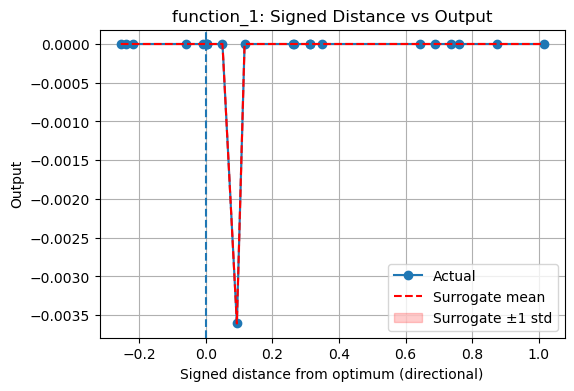

C:\Users\at-se\anaconda3\Lib\site-packages\torch\nn\modules\loss.py:626: UserWarning: Using a target size (torch.Size([22, 1])) that is different to the input size (torch.Size([1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)



 DATA_MAX=0.0000
Next suggestion:
  Acquisition used : UCB
  Acquisition score: 0.001383
  Model prediction  : -0.000009
  Neural Network prediction : [-0.00016384]
  Suggested X      : [0.37121387 0.54402018]
mu: [ 0.02867178  0.17132187  0.08394427 ...  0.07523719 -0.05389205
  0.21602518], sigma: [0.13341493 0.21241629 0.19972651 ... 0.19375832 0.06266518 0.16648729]
mu: [ 0.02867178  0.17132187  0.08394427 ...  0.07523719 -0.05389205
  0.21602518], sigma: [0.13341493 0.21241629 0.19972651 ... 0.19375832 0.06266518 0.16648729]
mu: [0.41783063], sigma: [0.18127962]
mu: [0.49933708], sigma: [0.12698128]
RBF(length_scale=[0.0573, 0.467]) + WhiteKernel(noise_level=0.021)


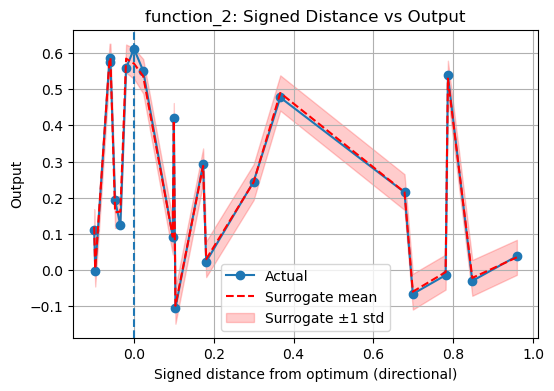

C:\Users\at-se\anaconda3\Lib\site-packages\torch\nn\modules\loss.py:626: UserWarning: Using a target size (torch.Size([22, 1])) that is different to the input size (torch.Size([1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)



 DATA_MAX=0.6112
Next suggestion:
  Acquisition used : UCB
  Acquisition score: 0.626318
  Model prediction  : 0.499337
  Neural Network prediction : [0.25914124]
  Suggested X      : [6.3456837e-01 6.1379913e-04]
mu: [-0.08644726 -0.05910097 -0.29140491 ... -0.10030103 -0.02910778
 -0.06490097], sigma: [0.03502552 0.02540364 0.02091915 ... 0.02330093 0.01982534 0.02164047]
mu: [-0.08644726 -0.05910097 -0.29140491 ... -0.10030103 -0.02910778
 -0.06490097], sigma: [0.03502552 0.02540364 0.02091915 ... 0.02330093 0.01982534 0.02164047]
mu: [-0.0189983], sigma: [0.02718825]
mu: [-0.01892729], sigma: [0.02713655]
RBF(length_scale=[100, 100, 0.0733]) + WhiteKernel(noise_level=0.0259)


C:\Users\at-se\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\at-se\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


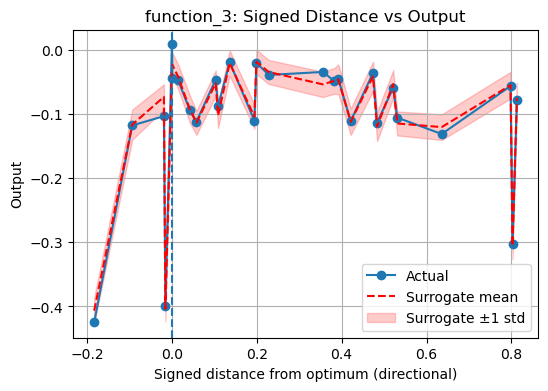

C:\Users\at-se\anaconda3\Lib\site-packages\torch\nn\modules\loss.py:626: UserWarning: Using a target size (torch.Size([27, 1])) that is different to the input size (torch.Size([1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)



 DATA_MAX=0.0091
Next suggestion:
  Acquisition used : UCB
  Acquisition score: 0.008209
  Model prediction  : -0.018927
  Neural Network prediction : [-0.09748778]
  Suggested X      : [0.82119381 0.07193934 0.86625449]
mu: [-18.32512306  -7.44489793 -27.08404326 ... -13.49787879 -17.18871546
 -14.19728542], sigma: [2.99614508 0.73177245 1.15708636 ... 1.39123239 3.91595273 2.2878173 ]
mu: [-18.32512306  -7.44489793 -27.08404326 ... -13.49787879 -17.18871546
 -14.19728542], sigma: [2.99614508 0.73177245 1.15708636 ... 1.39123239 3.91595273 2.2878173 ]
mu: [-0.55548442], sigma: [0.59182198]
mu: [-0.55548442], sigma: [0.59182198]
RBF(length_scale=[0.632, 0.612, 0.623, 0.599]) + WhiteKernel(noise_level=0.00278)


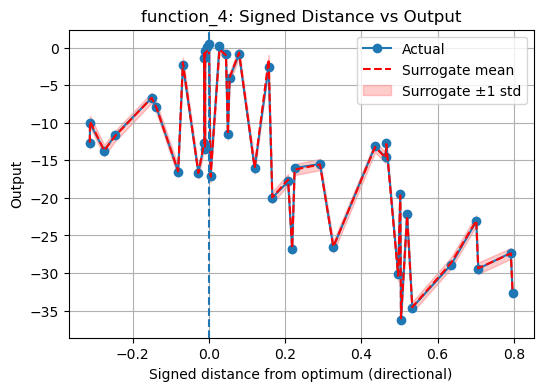

C:\Users\at-se\anaconda3\Lib\site-packages\torch\nn\modules\loss.py:626: UserWarning: Using a target size (torch.Size([42, 1])) that is different to the input size (torch.Size([1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)



 DATA_MAX=0.5065
Next suggestion:
  Acquisition used : EI
  Acquisition score: 0.008209
  Model prediction  : -0.555484
  Neural Network prediction : [-0.08447878]
  Suggested X      : [0.32803601 0.37314086 0.39301479 0.41057231]
mu: [101.35901659 151.58739842   3.63760457 ...  67.28916474 954.77326942
 -21.89849245], sigma: [608.37760936 490.24578841 389.82747416 ... 678.49976802 487.55405018
 381.79939938]
mu: [101.35901659 151.58739842   3.63760457 ...  67.28916474 954.77326942
 -21.89849245], sigma: [608.37760936 490.24578841 389.82747416 ... 678.49976802 487.55405018
 381.79939938]
mu: [5636.60573089], sigma: [235.06382984]
mu: [5636.60573089], sigma: [235.06382984]
3.13**2 * Matern(length_scale=[3.47, 2.86, 3.94, 2.1], nu=1.5) + WhiteKernel(noise_level=0.00642)


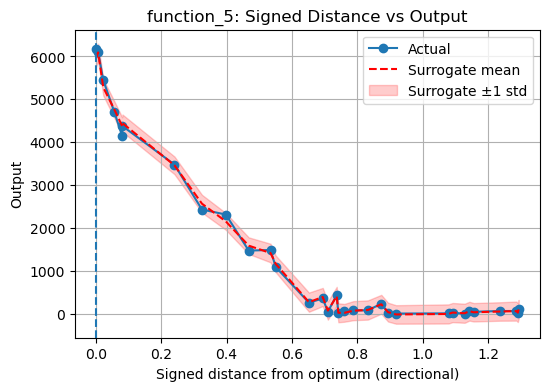

C:\Users\at-se\anaconda3\Lib\site-packages\torch\nn\modules\loss.py:626: UserWarning: Using a target size (torch.Size([32, 1])) that is different to the input size (torch.Size([1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)



 DATA_MAX=6182.7468
Next suggestion:
  Acquisition used : EI
  Acquisition score: 0.803672
  Model prediction  : 5636.605731
  Neural Network prediction : [0.41032392]
  Suggested X      : [0.95959918 0.92111163 0.8903641  0.99678875]


In [ ]:
# ======================================
# Execution point -> run from here
# ======================================

if __name__ == "__main__":
    load_weekly_data()
    functions = get_function_directories()
    run_all(functions)


